In [16]:
import pickle 
from pathlib import Path 
import copy 
import open3d as o3d 
import pandas as pd
import numpy as np 
# from aligner import Aligner
import gopropy
import matplotlib.pyplot as plt

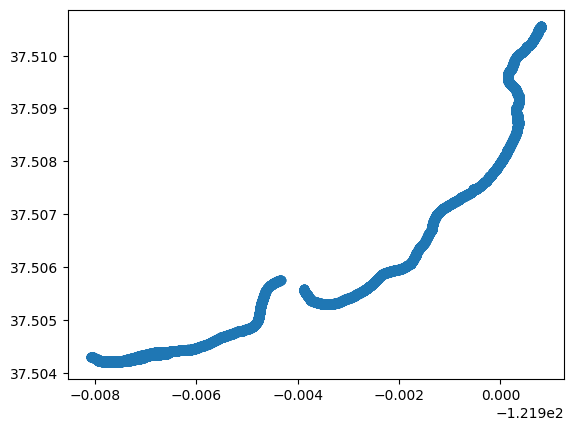

In [5]:
gps_dfs = []
for i in range(1,7): 
    telemetry = gopropy.load(f'/home/ape/Documents/MapperGoProVids/mp{i}.MP4')
    gps = telemetry.get_stream('GPS (Lat., Long., Alt., 2D speed, 3D speed)')
    gps_df = gps.to_dataframe()
    gps_dfs.append(gps_df)

gps_df = pd.concat(gps_dfs)
# gps_df.to_csv('gps_data.csv', index=False)

plt.scatter(gps_df['lon'], gps_df['lat'])


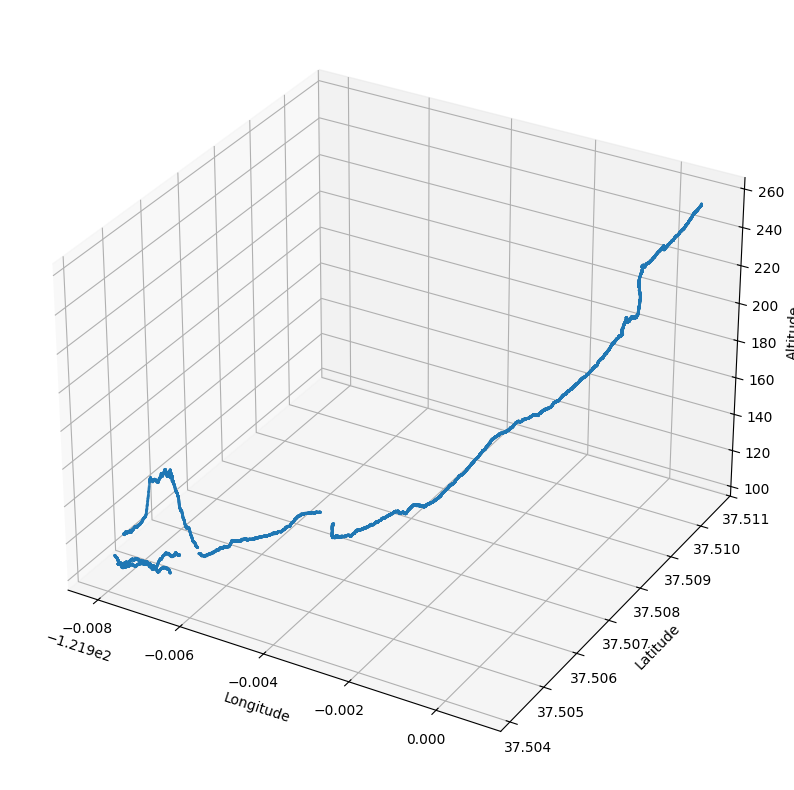

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gps_df['lon'], gps_df['lat'], gps_df['alt'], s=1)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude')
plt.grid()
plt.show()


In [ ]:
telemetry.

'HERO10_BLACK'

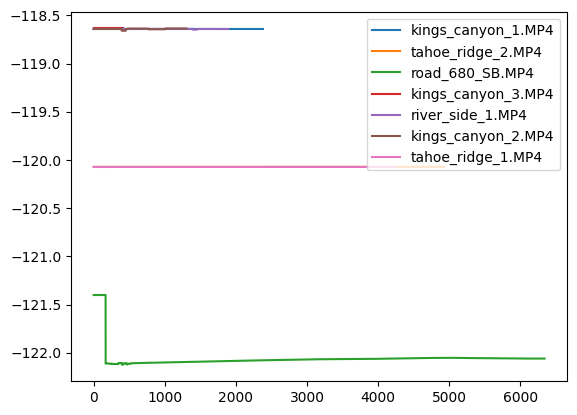

In [15]:
folder = Path("/home/ape/Documents/MapperGoProVids")
for file in folder.glob("*.MP4"):
    telemetry = gopropy.load(file)
    gps = telemetry.get_stream('GPS (Lat., Long., Alt., 2D speed, 3D speed)')
    gps_df = gps.to_dataframe()
    plt.plot(gps_df['lon'], label = file.name)
plt.legend()
plt.show()


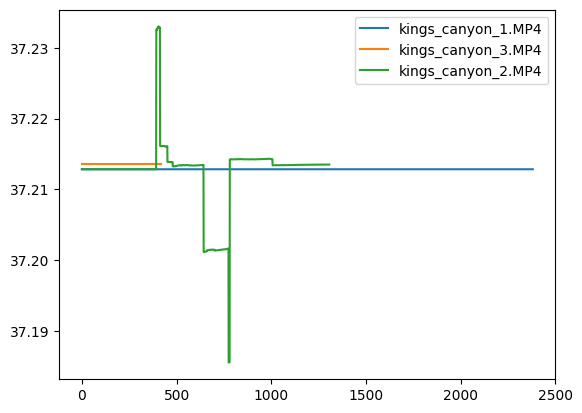

In [7]:
folder = Path("/home/ape/Documents/MapperGoProVids")
for file in folder.glob("*.MP4"):
    if 'kings_canyon' not in file.name:
        continue
    telemetry = gopropy.load(file)
    gps = telemetry.get_stream('GPS (Lat., Long., Alt., 2D speed, 3D speed)')
    gps_df = gps.to_dataframe()
    plt.plot(gps_df['lat'], label = file.name)
plt.legend()
plt.show()


In [3]:
# load ply files in folder 

folder = Path("/home/ape/repos/must3rdemo/must3r/test_dir")
ply_files = list(folder.glob("*.ply"))

# load ply files 
pcds = [o3d.io.read_point_cloud(ply_file) for ply_file in ply_files]
source = pcds[0]
target = pcds[3]

In [ ]:
def align_sequential_icp(point_clouds:list[o3d.geometry.PointCloud])->list[o3d.geometry.PointCloud]:
    # align the pointclouds sequentially using the ICP algorithm 
    for i in range(len(point_clouds) - 1):
        source = point_clouds[i]
        target = point_clouds[i + 1]
        # do global registration first
        source, target, source_down, target_down, source_fpfh, target_fpfh = prepare_dataset(0.05, source, target)
        initial_global_registration = execute_global_registration(source_down, target_down, source_fpfh, target_fpfh, 0.05)

        # then do ICP
        icp_result = o3d.pipelines.registration.registration_icp(
            source, target, 0.075, initial_global_registration.transformation,
            o3d.pipelines.registration.TransformationEstimationPointToPoint())
        # return icp_result
        # print(icp_result)
        # print(icp_result.transformation)
        point_clouds[i + 1] = point_clouds[i + 1].transform(icp_result.transformation)
        # point_clouds[i + 1] = icp_result.transformation @ point_clouds[i + 1]

        
    return point_clouds
icp_result = align_sequential_icp(pcds)

:: Load two point clouds and disturb initial pose.
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
:: Downsample with a voxel size 0.050.
:: Estimate normal with search radius 0.100.
:: Compute FPFH feature with search radius 0.250.
:: Downsample with a voxel size 0.050.
:: Estimate normal with search radius 0.100.
:: Compute FPFH feature with search radius 0.250.
:: RANSAC registration on downsampled point clouds.
   Since the downsampling voxel size is 0.050,
   we use a liberal distance threshold 0.075.
:: Load two point clouds and disturb initial pose.
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
:: Downsample with a voxel size 0.050.
:: Estim

In [1]:
def draw_registration_result(source, target, transformation, override_color=False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if override_color:
        source_temp.paint_uniform_color([1, 0.706, 1])
        target_temp.paint_uniform_color([0, 0.651, 1])
    source_temp.transform(transformation)
    
    o3d.visualization.draw_geometries([source_temp, target_temp],
                                    #   zoom=0.4459,
                                    #   front=[0.9288, -0.2951, -0.2242],
                                    #   lookat=[1.6784, 2.0612, 1.4451],
                                    #   up=[-0.3402, -0.9189, -0.1996], 
                                    )
def execute_global_registration(source_down, target_down, source_fpfh,
                                target_fpfh, voxel_size):
    distance_threshold = voxel_size * 1.5
    print(":: RANSAC registration on downsampled point clouds.")
    print("   Since the downsampling voxel size is %.3f," % voxel_size)
    print("   we use a liberal distance threshold %.3f." % distance_threshold)
    result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        source_down, target_down, source_fpfh, target_fpfh, True,
        distance_threshold,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        3, [
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(
                0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(
                distance_threshold)
        ], o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999))
    return result
def preprocess_point_cloud(pcd, voxel_size):
    print(":: Downsample with a voxel size %.3f." % voxel_size)
    pcd_down = pcd.voxel_down_sample(voxel_size)

    radius_normal = voxel_size * 2
    print(":: Estimate normal with search radius %.3f." % radius_normal)
    pcd_down.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

    radius_feature = voxel_size * 5
    print(":: Compute FPFH feature with search radius %.3f." % radius_feature)
    pcd_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down,
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
    return pcd_down, pcd_fpfh

def prepare_dataset(voxel_size, source,  target):
    print(":: Load two point clouds and disturb initial pose.")


    trans_init = np.asarray([[0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0],
                             [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0]])
    source.transform(trans_init)
    draw_registration_result(source, target, np.eye(4))

    source_down, source_fpfh = preprocess_point_cloud(source, voxel_size)
    target_down, target_fpfh = preprocess_point_cloud(target, voxel_size)
    return source, target, source_down, target_down, source_fpfh, target_fpfh

In [5]:
draw_registration_result(source, target, np.eye(4)) 

[Open3D INFO] Window window_0 created.
[Open3D INFO] EGL headless mode enabled.
[Open3D INFO] ICE servers: ["stun:stun.l.google.com:19302", "turn:user:password@34.69.27.100:3478", "turn:user:password@34.69.27.100:3478?transport=tcp"]
[Open3D INFO] Set WEBRTC_STUN_SERVER environment variable add a customized WebRTC STUN server.
[Open3D INFO] WebRTC Jupyter handshake mode enabled.
FEngine (64 bits) created at 0x768519942010 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


KeyboardInterrupt: 

In [2]:
# Compare the results in two folders side by side, offsetting one set for visual clarity

from pathlib import Path
import open3d as o3d
import numpy as np

# Define the two folders to compare
folder1 = Path("/home/ape/repos/must3rdemo/must3r/test_dir/test_alignment_0.1")
folder2 = Path("/home/ape/repos/must3rdemo/must3r/test_dir/test_alignment/colored_icp_voxel0.1")
# Get the ply files from each folder
ply_files1 = sorted(folder1.glob("*.ply"))
ply_files2 = sorted(folder2.glob("*.ply"))

# Read point clouds
pcds1 = [o3d.io.read_point_cloud(str(ply_file)) for ply_file in ply_files1]
pcds2 = [o3d.io.read_point_cloud(str(ply_file)) for ply_file in ply_files2]

# Offset the second set of point clouds along the X axis for side-by-side comparison
offset = np.array([50.0, 0.0, 0.0])  # Adjust the value as needed for your data
for pcd in pcds2:
    pcd.translate(offset)

print("Showing both results side by side in one window (left: Alignment 1.0, right: Alignment 0.1)")
o3d.visualization.draw_geometries(pcds1 + pcds2, window_name="Side-by-Side Comparison")


Showing both results side by side in one window (left: Alignment 1.0, right: Alignment 0.1)


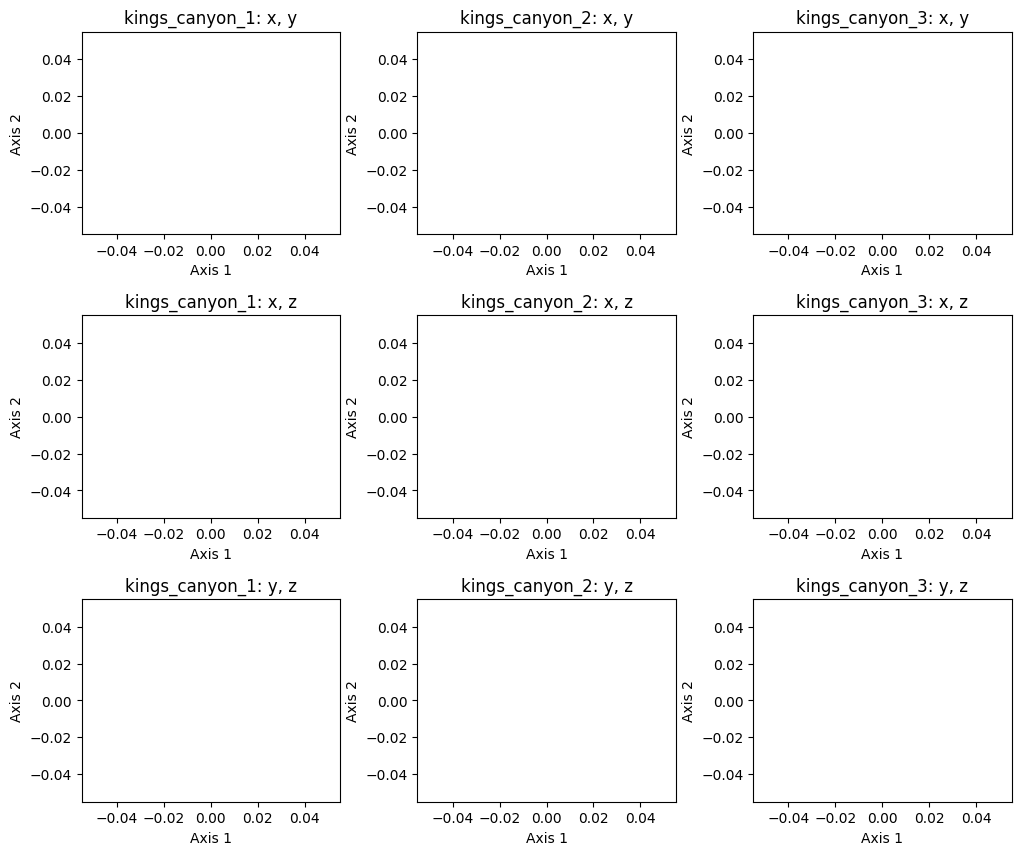

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 3, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Names of 'kings_canyon_1', 'kings_canyon_2', 'kings_canyon_3'
names = ['kings_canyon_1', 'kings_canyon_2', 'kings_canyon_3']
for i, name in enumerate(names):
    pc_path = f"data/output_kings_canyon/kings_canyon_orb_slam_20251231_182112/outputs/{name}/aligned_pointcloud.ply"
    pc = o3d.io.read_point_cloud(pc_path)
    points = np.asarray(pc.points)
    colors = np.asarray(pc.colors) if pc.has_colors() else None


    axs[0, i].scatter(points[:, 0], points[:, 1], c=colors, s=2)
    axs[0, i].set_title(f"{name}: x, y")
    axs[1, i].scatter(points[:, 0], points[:, 2], c=colors, s=2)
    axs[1, i].set_title(f"{name}: x, z")
    axs[2, i].scatter(points[:, 1], points[:, 2], c=colors, s=2)
    axs[2, i].set_title(f"{name}: y, z")

for row in axs:
    for ax in row:
        ax.set_xlabel('Axis 1')
        ax.set_ylabel('Axis 2')

plt.show()
plt.show()


In [25]:
pc = o3d.io.read_point_cloud("/workspace/output/vggt_gopro/vggt_trail_test_20260111_010514/outputs/mp1/aligned_pointcloud.ply")
points = np.asarray(pc.points)
colors = np.asarray(pc.colors)


In [22]:
points.shape

(240686628, 3)

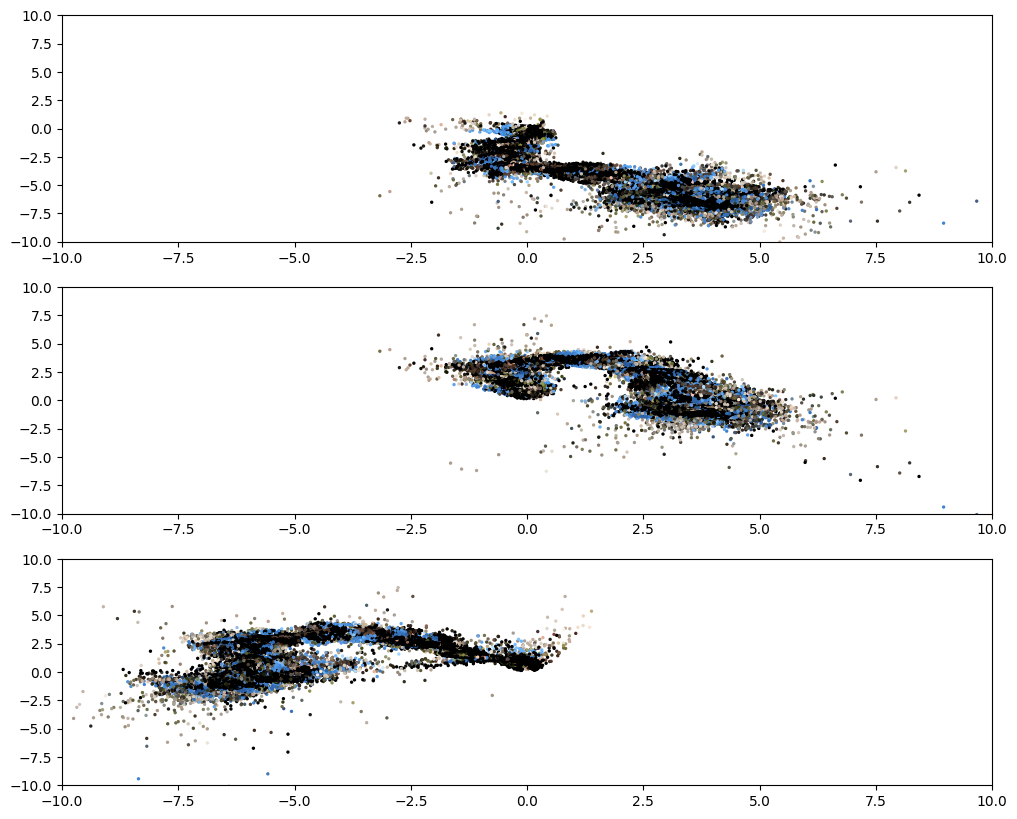

In [23]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10))
pts = points[::10000] 
x = pts[:, 0]
y = pts[:, 1]
z = pts[:, 2]

c = colors[::10000]

axs[0].scatter(x, y, c=c, s=2)
axs[1].scatter(x, z, c=c, s=2)
axs[2].scatter(y, z, c=c, s=2)

for ax in axs:
    ax.set_xlim([-10, 10])
    ax.set_ylim([-10, 10])
plt.show()


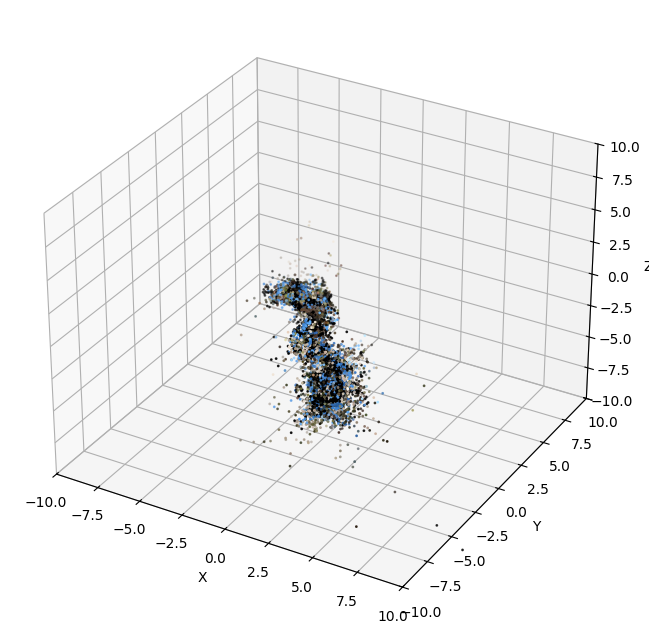

In [24]:
points = np.asarray(pc.points)
colors = np.asarray(pc.colors)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Downsample for faster plotting if there are a lot of points
step = max(points.shape[0] // 10000, 1)
pts = points[::step]
cls = colors[::step]
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=cls, s=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
plt.show()

